In [1]:

# =========================
# Transfer Learning: ResNet50
# Land Cover Classification
# Urban | Forest | Water
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


In [15]:

# -------------------------
# CONFIG
# -------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 2
NUM_CLASSES = 3


In [16]:

# CHANGE THIS PATH ONLY
DATASET_PATH = "data"   # data/Urban, data/Forest, data/Water


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 16500 files belonging to 3 classes.
Using 13200 files for training.
Found 16500 files belonging to 3 classes.
Using 3300 files for validation.
Classes: ['Forest', 'Urban', 'Water']


In [17]:

# -------------------------
# DATA AUGMENTATION
# -------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])


In [18]:

# -------------------------
# MODEL
# -------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze backbone

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)



In [19]:

# -------------------------
# COMPILE
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │      6,147 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:

# -------------------------
# TRAIN
# -------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/2
413/413 ━━━━━━━━━━━━━━━━━━━━ 507s 1s/step - accuracy: 0.9421 - loss: 0.1542 - val_accuracy: 0.9724 - val_loss: 0.0728
Epoch 2/2
413/413 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.9677 - loss: 0.0933 - val_accuracy: 0.9582 - val_loss: 0.1149


In [30]:
model.save("landcover_resnet50.keras")


In [22]:

# -------------------------
# SAVE MODEL
# -------------------------
model.save("landcover_resnet50.h5")
print("✅ Model saved as landcover_resnet50.h5")


✅ Model saved as landcover_resnet50.h5


In [23]:

# -------------------------
# SINGLE IMAGE PREDICTION
# -------------------------
import numpy as np
from tensorflow.keras.preprocessing import image


def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img = image.img_to_array(img)
    img = tf.expand_dims(img, axis=0)
    img = preprocess_input(img)

    preds = model.predict(img)
    class_id = np.argmax(preds[0])
    confidence = preds[0][class_id]

    return class_names[class_id], confidence


# Example:
label, conf = predict_image("data/Forest/Forest_1.jpg")
print(label, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Forest 0.6768333


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step


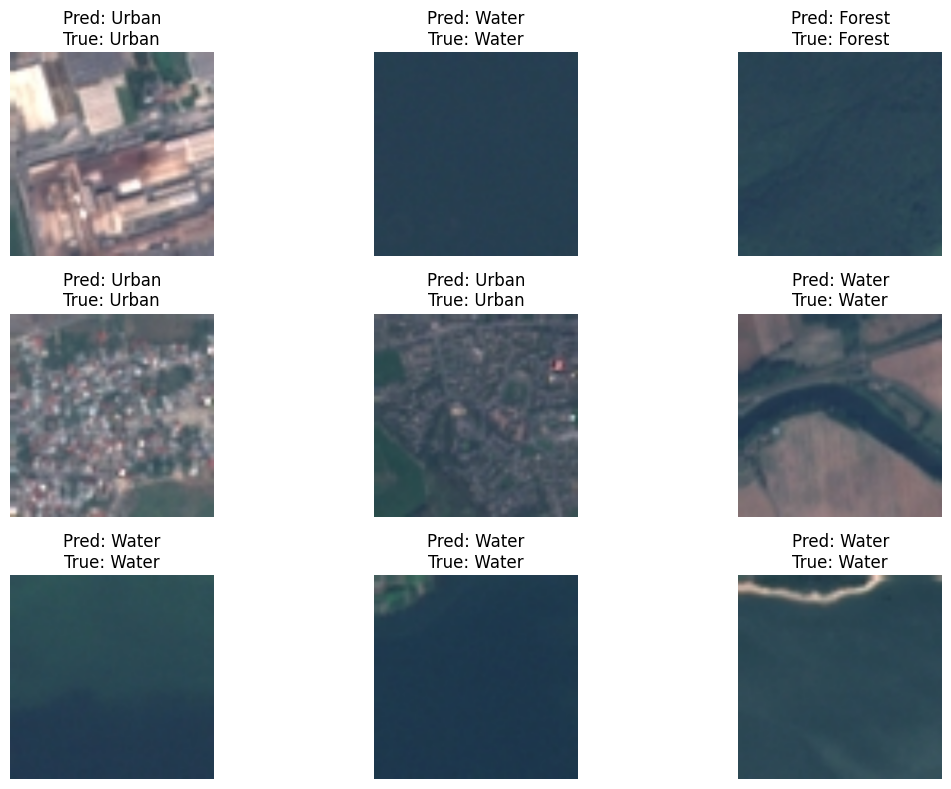

In [28]:
# =========================
# SHOW SAMPLE PREDICTIONS
# =========================
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_class = class_names[np.argmax(preds[i])]
        true_class = class_names[labels[i]]

        plt.title(f"Pred: {pred_class}\nTrue: {true_class}")
        plt.axis("off")
plt.tight_layout()
plt.show()